## Scope

- Source data: erratic subset from Inchscape Repo/data/processed/all_sku_history/collision_sales_erratic.csv
- Training window: Jan 2021 to Sep 2024
- Test window: Oct 2024 to Apr 2026
- Evaluation lag: 2 months
- Models covered: XGBoost, LightGBM, Random Forest, Lumpy Hurdle, Chronos 2 erratic-features, Chronos 2 erratic-features-plus-external, and Chronos T5-tiny
- Tree models are shown in baseline and tuned form; Chronos models are foundation models and are not locally tuned but were tuned in an external environment

In [9]:
# Colab/setup dependencies for this notebook.
# Run this cell first when using a fresh environment.

%pip install -q numpy pandas matplotlib statsmodels scikit-learn xgboost lightgbm torch ipython chronos-forecasting

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

repo_root = Path.cwd() / "Inchscape Repo"
data_path = repo_root / "data" / "processed" / "all_sku_history" / "collision_sales_erratic.csv"
external_features_path = Path.cwd() / "monthly_external_features (2).csv"
if not external_features_path.exists():
    external_features_path = repo_root / "data" / "external" / "monthly_external_features.csv"
results_dir = repo_root / "results" / "tables"
tuning_path = repo_root / "results" / "tuning" / "best_hyperparams_erratic.json"

erratic = pd.read_csv(data_path)
erratic["month"] = pd.to_datetime(erratic["month"])
erratic = erratic.sort_values(["sku_id", "month"]).reset_index(drop=True)

# Canonical alias used by legacy benchmark cells.
erratic_sales_data = erratic.copy()

# Lightweight aliases so the legacy erratic-analysis cells can run from repo files alone.
sales = erratic.copy()
sku_profile = pd.DataFrame({"sku_id": erratic["sku_id"].unique(), "demand_type": "Erratic"})
monthly_total = erratic.groupby("month", as_index=False)["demand"].sum().rename(columns={"demand": "total_demand"})
erratic_monthly_total = monthly_total.copy()

external_data = pd.read_csv(external_features_path)
external_data["date"] = pd.to_datetime(external_data["date"])
external_data["month_dt"] = pd.to_datetime(external_data[["year", "month"]].assign(day=1))

data_max = erratic["month"].max()
test_end = data_max
test_start = test_end - pd.DateOffset(months=18)
train_end = test_start - pd.DateOffset(days=1)

train_data = erratic[erratic["month"] <= train_end].copy()
test_data = erratic[(erratic["month"] >= test_start) & (erratic["month"] <= test_end)].copy()

print("Erratic dataset shape:", erratic.shape)
print("Unique SKUs:", erratic["sku_id"].nunique())
print("External features path:", external_features_path)
print("External features shape:", external_data.shape)
print("Train window:", train_data["month"].min(), "to", train_data["month"].max())
print("Test window:", test_data["month"].min(), "to", test_data["month"].max())
print("Train rows:", len(train_data), "Test rows:", len(test_data))

Erratic dataset shape: (23019, 53)
Unique SKUs: 396
External features path: c:\Users\14bcr\OneDrive\Documents\GitHub\Lumpy_Fellas-\monthly_external_features (2).csv
External features shape: (64, 87)
Train window: 2021-01-01 00:00:00 to 2024-09-01 00:00:00
Test window: 2024-10-01 00:00:00 to 2026-04-01 00:00:00
Train rows: 15589 Test rows: 7430


In [11]:
def pooled_wmape(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    denominator = np.abs(actual).sum()
    if denominator == 0:
        return np.nan
    return np.abs(actual - forecast).sum() / denominator * 100

def format_percent(value):
    return f"{value:.2f}%" if pd.notna(value) else "n/a"

# This is the same pooled WMAPE convention used in the evaluation scripts:
# sum(abs(actual - forecast)) / sum(abs(actual)) * 100

# Importing data

When ran in this Repo, this notebook will draw from the available data files. If not, then in order to run it requires the set of pre-processed erratic data and external features that were detailed in other notebooks.

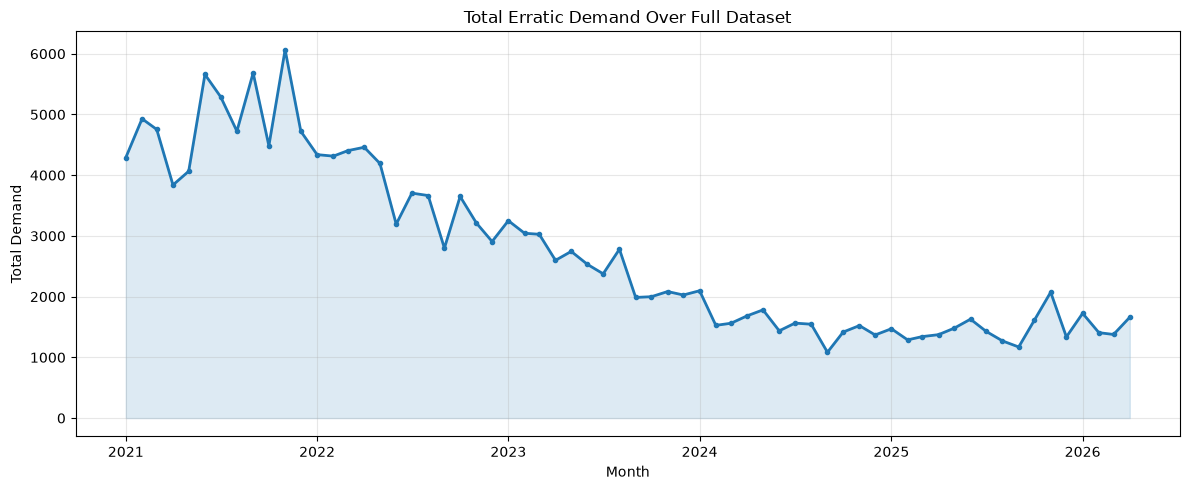

Coverage: 2021-01 to 2026-04 (64 months)


In [44]:
# Total erratic demand over the full dataset (all available months)
erratic_total_full = (
    erratic.groupby("month", as_index=False)["demand"]
    .sum()
    .sort_values("month")
)

plt.figure(figsize=(12, 5))
plt.plot(
    erratic_total_full["month"],
    erratic_total_full["demand"],
    color="#1f77b4",
    linewidth=2,
    marker="o",
    markersize=3,
)
plt.fill_between(
    erratic_total_full["month"],
    erratic_total_full["demand"],
    alpha=0.15,
    color="#1f77b4",
)
plt.title("Total Erratic Demand Over Full Dataset")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Coverage:",
    erratic_total_full["month"].min().strftime("%Y-%m"),
    "to",
    erratic_total_full["month"].max().strftime("%Y-%m"),
    f"({len(erratic_total_full)} months)",
)

## Erratic Demand EDA and Benchmarking 

Erratic demand has the smallest number of SKUs, not counting SKUs with no demand. Their quantities vary significantly which suggests low autocorrelation but let's check this is the case and compare their autocorrelation with the data as a whole:

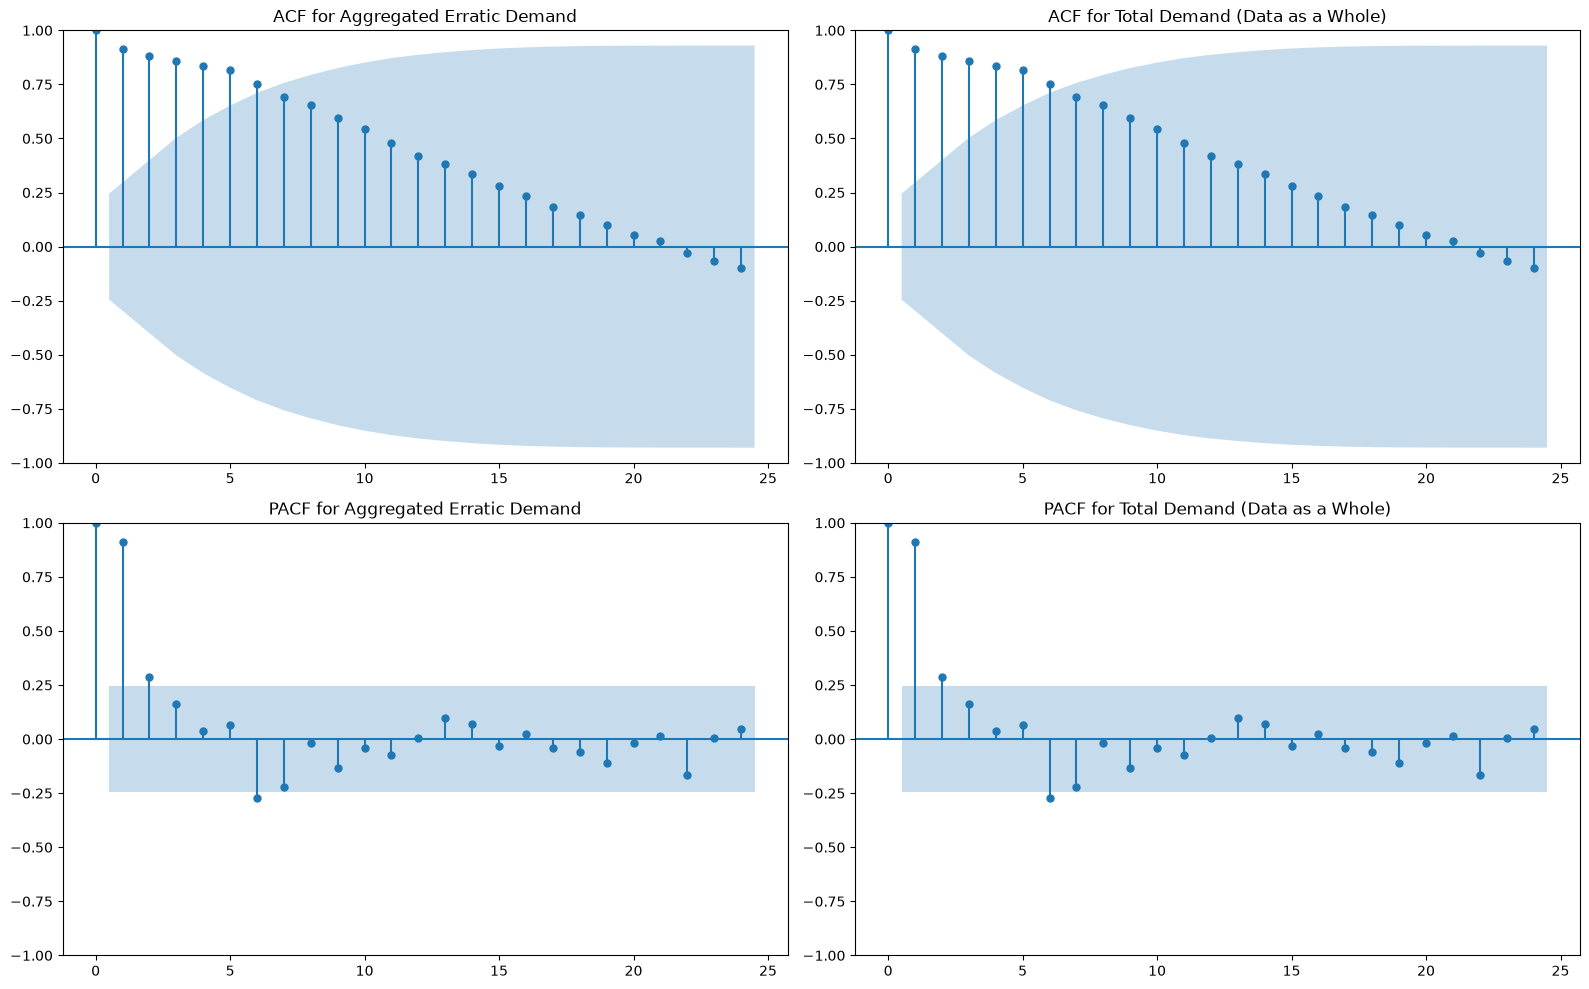

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. Get SKUs classified as 'Erratic'
erratic_skus = sku_profile[sku_profile['demand_type'] == 'Erratic']['sku_id']

# 2. Filter sales data for these erratic SKUs
erratic_sales = sales[sales['sku_id'].isin(erratic_skus)]

# 3. Aggregate erratic demand by month to create a single time series
erratic_monthly_total = erratic_sales.groupby('month')['demand'].sum().reset_index()

# Ensure the 'total_demand' column name is consistent if needed (monthly_total already has it)
erratic_monthly_total = erratic_monthly_total.rename(columns={'demand': 'total_demand'})

# Set up the plots for comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot ACF for Erratic Demand
plot_acf(erratic_monthly_total['total_demand'], ax=axes[0, 0], lags=24)
axes[0, 0].set_title('ACF for Aggregated Erratic Demand')

# Plot PACF for Erratic Demand
plot_pacf(erratic_monthly_total['total_demand'], ax=axes[1, 0], lags=24)
axes[1, 0].set_title('PACF for Aggregated Erratic Demand')

# Plot ACF for Total Demand (Data as a Whole)
plot_acf(monthly_total['total_demand'], ax=axes[0, 1], lags=24)
axes[0, 1].set_title('ACF for Total Demand (Data as a Whole)')

# Plot PACF for Total Demand (Data as a Whole)
plot_pacf(monthly_total['total_demand'], ax=axes[1, 1], lags=24)
axes[1, 1].set_title('PACF for Total Demand (Data as a Whole)')

plt.tight_layout()
plt.show()

Contrary to what we assumed, erratic demand seems have a similar PACF and ACF as the data as a whole at earlier lags, with the first two lags being significant. Additionally, erratic demand shows significant negative PACF at later lags.

#### Benchmarking

Let's create some simple models to compare our more complex models against as well as defining our WMAPE function and rolling-origin validation strategy.

In [37]:
def wmape(*args):
    """
    Pooled WMAPE matching the repo benchmark logic.

    Supports legacy call sites that still pass (months, actual, forecast)
    as well as the direct (actual, forecast) form.
    """
    if len(args) == 2:
        actual, forecast = args
    elif len(args) >= 3:
        actual, forecast = args[1], args[2]
    else:
        raise TypeError("wmape expects either (actual, forecast) or (months, actual, forecast)")

    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    denominator = np.abs(actual).sum()
    if denominator == 0:
        return np.nan
    return np.abs(actual - forecast).sum() / denominator * 100

def rolling_origin_validation(data_df, model_func, horizon=1, initial_train_months=36, lag_months=2):
    """
    Performs rolling-origin (walk-forward) validation for time series forecasting.

    Args:
        data_df (pd.DataFrame): DataFrame containing 'month', 'sku_id', and 'demand' columns.
                                Assumes data is sorted by sku_id and month.
        model_func (callable): A function that takes train_df and returns a forecast for the next `horizon` periods.
                                The model_func should return a DataFrame with 'sku_id', 'month', 'demand' (forecast) columns.
        horizon (int): The number of months to forecast into the future at each step.
        initial_train_months (int): The minimum number of months for the initial training set.
        lag_months (int): How far back actuals must be available before evaluation.

    Returns:
        pd.DataFrame: DataFrame containing actual and forecasted values for each SKU and month.
    """
    results = []
    all_months = sorted(data_df['month'].unique())

    if len(all_months) < initial_train_months + lag_months + horizon:
        print("Not enough data for the specified initial training months and horizon.")
        return pd.DataFrame()

    # Determine the start month for the first test set
    first_test_month_idx = initial_train_months

    while first_test_month_idx < len(all_months):
        train_end_idx = first_test_month_idx - lag_months
        if train_end_idx < 0:
            break
        train_end_month = all_months[train_end_idx]
        test_start_month = all_months[first_test_month_idx]

        # Define training and testing periods
        train_df = data_df[data_df['month'] <= train_end_month]
        test_df = data_df[data_df['month'] >= test_start_month]

        # Limit test_df to the current horizon
        test_months_in_horizon = all_months[first_test_month_idx : first_test_month_idx + horizon]
        test_df = test_df[test_df['month'].isin(test_months_in_horizon)]

        if test_df.empty:
            break

        # Generate forecasts using the provided model function
        forecast_df = model_func(train_df, test_months_in_horizon)

        # Merge forecasts with actuals for evaluation
        evaluation_df = pd.merge(
            test_df[['sku_id', 'month', 'demand']],
            forecast_df[['sku_id', 'month', 'demand']].rename(columns={'demand': 'forecast'}),
            on=['sku_id', 'month'],
            how='left'
        )

        # Fill NaNs in forecast with 0 if an SKU is not forecasted for a particular month
        evaluation_df['forecast'] = evaluation_df['forecast'].fillna(0)

        results.append(evaluation_df)

        # Move the origin forward by the horizon length
        first_test_month_idx += horizon

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

In [38]:
import numpy as np

# --- Benchmark Model 2: Seasonal Naïve Forecast (Last Observed Seasonal Value) ---
def seasonal_naive_forecast_model(train_df, forecast_months, seasonal_period=12):
    """
    Implements the Seasonal Naïve forecast: uses the last observed value from the same season.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.
        seasonal_period (int): The length of the seasonal cycle (e.g., 12 for yearly seasonality).

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        if not sku_train_df.empty:
            # Get the last observed month in the training data
            last_train_month = sku_train_df['month'].iloc[-1]

            for forecast_month in forecast_months:
                # Find the month `seasonal_period` periods ago relative to the forecast_month
                # Use pandas.DateOffset to subtract months safely
                seasonal_lag_month = forecast_month - pd.DateOffset(months=seasonal_period)

                # Find the demand for the seasonal lag month within the training data
                seasonal_demand_row = sku_train_df[sku_train_df['month'] == seasonal_lag_month]

                if not seasonal_demand_row.empty:
                    seasonal_demand = seasonal_demand_row['demand'].iloc[0]
                    forecasts.append({'sku_id': sku, 'month': forecast_month, 'demand': seasonal_demand})
                else:
                    # Fallback to Naive (last observed) if seasonal lag is not available
                    # or forecast 0 if no history at all for the SKU in train_df
                    last_observed_demand = sku_train_df['demand'].iloc[-1]
                    forecasts.append({'sku_id': sku, 'month': forecast_month, 'demand': last_observed_demand})
        else:
            # If SKU has no history in train_df, forecast 0
            for forecast_month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': forecast_month, 'demand': 0})

    return pd.DataFrame(forecasts)

print("Running Seasonal Naïve forecast validation...")
seasonal_naive_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=seasonal_naive_forecast_model,
    horizon=1, # Forecast one month ahead at each step
    initial_train_months=36, # Use 3 years of data for initial training
    lag_months=2
)

# Calculate WMAPE for Seasonal Naïve forecast
if not seasonal_naive_results.empty:
    seasonal_naive_wmape = wmape(seasonal_naive_results['demand'], seasonal_naive_results['forecast'])
    print(f"Seasonal Naïve Forecast WMAPE for Erratic Demand: {seasonal_naive_wmape:.2f}%")
else:
    print("Seasonal Naïve forecast results are empty.")

Running Seasonal Naïve forecast validation...
Seasonal Naïve Forecast WMAPE for Erratic Demand: 100.40%


In [39]:
# --- Benchmark Model 3: Simple Moving Average (SMA) Forecast ---
def sma_forecast_model(train_df, forecast_months, window_size=3):
    """
    Implements the Simple Moving Average forecast: uses the average of the last `window_size` observed demands.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.
        window_size (int): The number of periods to include in the moving average.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        if not sku_train_df.empty and len(sku_train_df) >= window_size:
            # Calculate SMA from the last `window_size` demands
            sma_value = sku_train_df['demand'].iloc[-window_size:].mean()
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': sma_value})
        elif not sku_train_df.empty:
            # If not enough history for SMA, fall back to Naïve (last observed demand)
            last_demand = sku_train_df['demand'].iloc[-1]
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
        else:
            # If SKU has no history in train_df, forecast 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})

    return pd.DataFrame(forecasts)


print("Running 3-month Simple Moving Average forecast validation...")
sma_3_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=lambda df, months: sma_forecast_model(df, months, window_size=3),
    horizon=1,
    initial_train_months=36,
    lag_months=2
)

# Calculate WMAPE for 3-month SMA forecast
if not sma_3_results.empty:
    sma_3_wmape = wmape(sma_3_results['demand'], sma_3_results['forecast'])
    print(f"3-month SMA Forecast WMAPE for Erratic Demand: {sma_3_wmape:.2f}%")
else:
    print("3-month SMA forecast results are empty.")

Running 3-month Simple Moving Average forecast validation...
3-month SMA Forecast WMAPE for Erratic Demand: 67.36%


In [40]:
print("Running 6-month Simple Moving Average forecast validation...")
sma_6_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=lambda df, months: sma_forecast_model(df, months, window_size=6),
    horizon=1,
    initial_train_months=36,
    lag_months=2
)

# Calculate WMAPE for 6-month SMA forecast
if not sma_6_results.empty:
    sma_6_wmape = wmape(sma_6_results['demand'], sma_6_results['forecast'])
    print(f"6-month SMA Forecast WMAPE for Erratic Demand: {sma_6_wmape:.2f}%")
else:
    print("6-month SMA forecast results are empty.")

Running 6-month Simple Moving Average forecast validation...
6-month SMA Forecast WMAPE for Erratic Demand: 65.86%


In [41]:
# --- Benchmark Model 4: Croston's Method ---
def croston_forecast_model(train_df, forecast_months):
    """
    Implements Croston's Method for intermittent demand forecasting.
    Forecasts average demand interval and average demand size separately.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        demand_occurrences = sku_train_df[sku_train_df['demand'] > 0]['demand']

        if len(demand_occurrences) < 2: # Need at least two demand occurrences to calculate intervals
            # Fallback to Naive (last observed) or 0 if not enough data
            if not sku_train_df.empty:
                last_demand = sku_train_df['demand'].iloc[-1]
            else:
                last_demand = 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
            continue

        # Calculate average demand size
        avg_demand_size = demand_occurrences.mean()

        # Calculate average inter-arrival time (interval)
        # Get indices of demand occurrences
        demand_indices = sku_train_df[sku_train_df['demand'] > 0].index
        # Calculate time differences between demand occurrences
        intervals = (demand_indices[1:] - demand_indices[:-1]).to_series()
        avg_interval = intervals.mean() if not intervals.empty else 1 # Default to 1 if only one occurrence

        # Croston's forecast is average demand size / average interval
        croston_forecast = avg_demand_size / avg_interval if avg_interval > 0 else avg_demand_size # Avoid division by zero
        croston_forecast = max(0, croston_forecast) # Ensure forecast is non-negative

        for month in forecast_months:
            forecasts.append({'sku_id': sku, 'month': month, 'demand': croston_forecast})

    return pd.DataFrame(forecasts)


print("Running Croston's Method forecast validation...")
croston_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=croston_forecast_model,
    horizon=1,
    initial_train_months=36,
    lag_months=2
)

# Calculate WMAPE for Croston's Method
if not croston_results.empty:
    croston_wmape = wmape(croston_results['demand'], croston_results['forecast'])
    print(f"Croston's Method Forecast WMAPE for Erratic Demand: {croston_wmape:.2f}%")
else:
    print("Croston's Method forecast results are empty.")

Running Croston's Method forecast validation...
Croston's Method Forecast WMAPE for Erratic Demand: 152.12%


In [42]:
# --- Benchmark Model 5: Syntetos-Boylan Approximation (SBA) ---
def sba_forecast_model(train_df, forecast_months):
    """
    Implements the Syntetos-Boylan Approximation (SBA) for intermittent demand forecasting.
    SBA is an adjusted version of Croston's method.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        demand_occurrences = sku_train_df[sku_train_df['demand'] > 0]['demand']

        if len(demand_occurrences) < 2:
            # Fallback to Naive (last observed) or 0 if not enough data
            if not sku_train_df.empty:
                last_demand = sku_train_df['demand'].iloc[-1]
            else:
                last_demand = 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': last_demand})
            continue

        avg_demand_size = demand_occurrences.mean()

        demand_indices = sku_train_df[sku_train_df['demand'] > 0].index
        intervals = (demand_indices[1:] - demand_indices[:-1]).to_series()
        avg_interval = intervals.mean() if not intervals.empty else 1

        # Croston's forecast
        croston_f = avg_demand_size / avg_interval if avg_interval > 0 else avg_demand_size

        # SBA correction factor
        sba_correction_factor = 1 - (1 / avg_interval)

        # SBA forecast
        sba_forecast = croston_f * sba_correction_factor
        sba_forecast = max(0, sba_forecast) # Ensure forecast is non-negative

        for month in forecast_months:
            forecasts.append({'sku_id': sku, 'month': month, 'demand': sba_forecast})

    return pd.DataFrame(forecasts)


print("Running Syntetos-Boylan Approximation (SBA) forecast validation...")
sba_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=sba_forecast_model,
    horizon=1,
    initial_train_months=36,
    lag_months=2
)

# Calculate WMAPE for SBA
if not sba_results.empty:
    sba_wmape = wmape(sba_results['demand'], sba_results['forecast'])
    print(f"SBA Forecast WMAPE for Erratic Demand: {sba_wmape:.2f}%")
else:
    print("SBA forecast results are empty.")

Running Syntetos-Boylan Approximation (SBA) forecast validation...
SBA Forecast WMAPE for Erratic Demand: 94.68%


In [43]:
# --- Benchmark Model 6: Teunter-Syntetos-Babai (TSB) Method ---
def tsb_forecast_model(train_df, forecast_months, alpha=0.1, beta=0.1):
    """
    Implements the Teunter-Syntetos-Babai (TSB) method for intermittent demand forecasting.

    Args:
        train_df (pd.DataFrame): Training data with 'sku_id', 'month', 'demand'.
        forecast_months (list): List of months for which to generate forecasts.
        alpha (float): Smoothing parameter for demand size (0 to 1).
        beta (float): Smoothing parameter for demand probability (0 to 1).

    Returns:
        pd.DataFrame: Forecasted demand for each SKU and month in the forecast_months.
    """
    forecasts = []
    for sku in train_df['sku_id'].unique():
        sku_train_df = train_df[train_df['sku_id'] == sku].sort_values('month')

        demand_history = sku_train_df['demand'].tolist()

        if len(demand_history) == 0:
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})
            continue

        # Initialize TSB parameters
        Lt = 0 # Smoothed average demand size
        Pt = 0 # Smoothed demand probability
        last_demand_occurrence = -1 # Index of the last demand occurrence
        last_interval = 0 # Length of the last interval without demand

        # Initial values (similar to original TSB implementation, first demand occurrence)
        first_demand_idx = -1
        for i, d in enumerate(demand_history):
            if d > 0:
                first_demand_idx = i
                Lt = d
                Pt = 1.0 # First demand implies probability of 1 for that period
                last_demand_occurrence = i
                break

        if first_demand_idx == -1:
            # No demand observed in history, forecast 0
            for month in forecast_months:
                forecasts.append({'sku_id': sku, 'month': month, 'demand': 0})
            continue

        # Apply TSB smoothing
        for i in range(first_demand_idx + 1, len(demand_history)):
            current_demand = demand_history[i]
            if current_demand > 0:
                # Demand occurred
                Lt = alpha * current_demand + (1 - alpha) * Lt
                interval_since_last_demand = i - last_demand_occurrence
                Pt = beta * (1 / interval_since_last_demand) + (1 - beta) * Pt
                last_demand_occurrence = i
                last_interval = 0
            else:
                # No demand occurred
                last_interval += 1
                Pt = Pt * (1 - beta)

        # Ensure Pt is not zero to avoid division by zero in forecast calculation
        Pt = max(Pt, 1e-6) # Smallest possible positive value

        # TSB forecast
        tsb_forecast_value = Lt * Pt
        tsb_forecast_value = max(0, tsb_forecast_value) # Ensure forecast is non-negative

        for month in forecast_months:
            forecasts.append({'sku_id': sku, 'month': month, 'demand': tsb_forecast_value})

    return pd.DataFrame(forecasts)


print("Running Teunter-Syntetos-Babai (TSB) forecast validation...")
tsb_results = rolling_origin_validation(
    data_df=erratic_sales_data,
    model_func=tsb_forecast_model,
    horizon=1,
    initial_train_months=36,
    lag_months=2
)

# Calculate WMAPE for TSB
if not tsb_results.empty:
    tsb_wmape = wmape(tsb_results['demand'], tsb_results['forecast'])
    print(f"TSB Forecast WMAPE for Erratic Demand: {tsb_wmape:.2f}%")
else:
    print("TSB forecast results are empty.")

Running Teunter-Syntetos-Babai (TSB) forecast validation...
TSB Forecast WMAPE for Erratic Demand: 79.06%


Interestingly, the simple moving average benchmark performs the best which at 65.86% which should inform our subsequent models.

## Supervised Tree based Models

First let's pre-process the features given to us in the data frame by removing all columns for which less than 80% of the rows have values for as well as normalisations

In [20]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print("--- Preprocessing for Erratic Demand Models ---")

# FIX: Instead of starting from raw erratic_sales_data, we check if df_preprocessed
# already exists with engineered features. If not, we initialize it.
if 'df_preprocessed' not in locals():
    print("Initializing df_preprocessed from raw data...")
    df_preprocessed = erratic_sales_data.copy()
else:
    print(f"Using existing df_preprocessed with {df_preprocessed.shape[1]} columns.")

# 1. Remove features with more than 20% missing values
missing_percentages = df_preprocessed.isnull().sum() / len(df_preprocessed)
columns_to_drop_missing = missing_percentages[missing_percentages > 0.20].index.tolist()

# We must be careful not to drop the target or critical IDs even if they have missing values (though they shouldn't here)
protected_cols = ['sku_id', 'month', 'demand']
columns_to_drop_missing = [c for c in columns_to_drop_missing if c not in protected_cols]

if columns_to_drop_missing:
    print(f"\nRemoving {len(columns_to_drop_missing)} columns with >20% missing values.")
    df_preprocessed = df_preprocessed.drop(columns=columns_to_drop_missing)

# 2. Apply normalization to numerical features
exclude_from_scaling = [
    'sku_id', 'month', 'demand', 'Date', 'ts_id', 'value',
    'COUNTRY_BRAND_CHANNEL', 'Country', 'Brand', 'Channel',
    'collision_flag', 'collision_flag_clean', 'is_collision'
]

numerical_cols = df_preprocessed.select_dtypes(include=np.number).columns.tolist()
features_to_scale = [col for col in numerical_cols if col not in exclude_from_scaling]

if features_to_scale:
    print(f"Applying StandardScaler to {len(features_to_scale)} features...")
    scaler = StandardScaler()
    df_preprocessed[features_to_scale] = scaler.fit_transform(df_preprocessed[features_to_scale].fillna(0))

print(f"Final shape: {df_preprocessed.shape}")
display(df_preprocessed.head())

--- Preprocessing for Erratic Demand Models ---
Initializing df_preprocessed from raw data...

Removing 9 columns with >20% missing values.
Applying StandardScaler to 33 features...
Final shape: (23019, 44)


,sku_id,month,demand,demand_type,row_is_collision,COUNTRY_BRAND_CHANNEL,Country,Brand,Channel,REVENUE,...,Private_Sector_Credit,Producer_Prices,Producer_Prices_Change,Retail_Sales_MoM,Total_Vehicle_Sales,Unemployed_Persons,Unemployment_Rate,Wages,REGION,collision_flag
0,0911912012000,2021-01-01,118.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,-0.392162,-1.179113,0.072980,-0.540503,-0.387330,0.698151,1.020605,-0.284214,AMERICAS,NON COLLISION
1,0911912012000,2021-02-01,226.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,-0.376344,-1.061223,0.530434,0.150039,-0.450320,0.777875,1.062107,-0.277041,AMERICAS,NON COLLISION
2,0911912012000,2021-03-01,25.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,-0.357859,-0.916823,1.100094,-0.248351,0.576345,0.794719,1.091751,-0.243191,AMERICAS,NON COLLISION
3,0911912012000,2021-04-01,69.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,-0.350786,-0.882697,1.212300,-2.080943,-0.098368,0.696692,1.026534,-0.219606,AMERICAS,NON COLLISION
4,0911912012000,2021-05-01,195.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,-0.333828,-0.655661,1.989109,7.108579,0.783624,0.527577,0.907957,-0.233327,AMERICAS,NON COLLISION


### XGBOOST

Given what we have found from our exploratory data analysis and our benchmarking, let's implement an XGBOOST model with all lags inputted as features as well as a 6 month moving average. Let's also create the features zero_streak (as negative PACF at certain lags implies long periods of low demand may result in high demand) and various short term demand vs long term demand comparisons to capture the relationship shown in the PACF plot.

In [21]:
import pandas as pd
import numpy as np

def engineer_features(df):
    """
    Engineers a set of time series features for an SKU-level demand forecasting model.
    """
    df = df.copy()
    df['month'] = pd.to_datetime(df['month'])
    df = df.sort_values(by=['sku_id', 'month']).reset_index(drop=True)

    print("Generating lag features...")
    for i in range(1, 25):
        df[f'lag_{i}'] = df.groupby('sku_id')['demand'].shift(i)

    print("Generating rolling mean features...")
    df['rolling_mean_6'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=6, min_periods=1).mean().shift(1))
    df['rolling_mean_3'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=3, min_periods=1).mean().shift(1))
    df['rolling_mean_12'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=12, min_periods=1).mean().shift(1))
    df['rolling_mean_24'] = df.groupby('sku_id')['demand'].transform(lambda x: x.rolling(window=24, min_periods=1).mean().shift(1))

    epsilon = 1e-6
    print("Generating rolling mean ratio and difference features...")
    df['rolling_mean_3_div_12'] = df['rolling_mean_3'] / (df['rolling_mean_12'] + epsilon)
    df['rolling_mean_6_div_24'] = df['rolling_mean_6'] / (df['rolling_mean_24'] + epsilon)
    df['rolling_mean_3_minus_12'] = df['rolling_mean_3'] - df['rolling_mean_12']
    df['rolling_mean_6_minus_24'] = df['rolling_mean_6'] - df['rolling_mean_24']

    print("Generating zero streak feature...")
    df['zero_streak'] = df.groupby('sku_id')['demand'].transform(
        lambda x: (x == 0).cumsum() - (x == 0).cumsum().where(x > 0).ffill().fillna(0)
    ).shift(1).fillna(0).astype(int)

    return df

if 'erratic_sales_data' in locals():
    print("Starting feature engineering...")
    # Generate features
    engineered_df = engineer_features(erratic_sales_data)

    # Identify the new columns created
    new_cols = [c for c in engineered_df.columns if c not in erratic_sales_data.columns]

    # Append these features to df_preprocessed based on sku_id and month
    if 'df_preprocessed' in locals():
        print("Merging engineered features into df_preprocessed...")
        df_preprocessed = pd.merge(
            df_preprocessed,
            engineered_df[['sku_id', 'month'] + new_cols],
            on=['sku_id', 'month'],
            how='left'
        )
        print(f"Feature engineering complete. df_preprocessed now has {df_preprocessed.shape[1]} columns.")
        display(df_preprocessed.head())
    else:
        print("Warning: df_preprocessed not found. Storing result in erratic_sales_features instead.")
        erratic_sales_features = engineered_df
else:
    print("Error: 'erratic_sales_data' not found.")

Starting feature engineering...
Generating lag features...
Generating rolling mean features...
Generating rolling mean ratio and difference features...
Generating zero streak feature...
Merging engineered features into df_preprocessed...
Feature engineering complete. df_preprocessed now has 77 columns.


,sku_id,month,demand,demand_type,row_is_collision,COUNTRY_BRAND_CHANNEL,Country,Brand,Channel,REVENUE,...,lag_24,rolling_mean_6,rolling_mean_3,rolling_mean_12,rolling_mean_24,rolling_mean_3_div_12,rolling_mean_6_div_24,rolling_mean_3_minus_12,rolling_mean_6_minus_24,zero_streak
0,0911912012000,2021-01-01,118.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,0911912012000,2021-02-01,226.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,NaN,118.0,118.000000,118.0,118.0,1.000000,1.0,0.000000,0.0,0
2,0911912012000,2021-03-01,25.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,NaN,172.0,172.000000,172.0,172.0,1.000000,1.0,0.000000,0.0,0
3,0911912012000,2021-04-01,69.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,NaN,123.0,123.000000,123.0,123.0,1.000000,1.0,0.000000,0.0,0
4,0911912012000,2021-05-01,195.0,Erratic,False,CHILE_SUZUKI_WHOLESALE,CHILE,SUZUKI,DISTRIBUTION,-0.468587,...,NaN,109.5,106.666667,109.5,109.5,0.974125,1.0,-2.833333,0.0,0


In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Repo-aligned imports and evaluation logic.
repo_src = repo_root / "src"
if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

from models.advanced import tree_forecast
from models.benchmarks import wmape_per_sku

print("Running XGBoost evaluation with repo-aligned protocol...")

# Match the repo's erratic rolling-evaluation split logic.
data = erratic.copy()
data["month"] = pd.to_datetime(data["month"])
data = data.sort_values(["sku_id", "month"]).reset_index(drop=True)
data["demand_type"] = "erratic"

data_max = data["month"].max()
test_end_local = data_max
test_start_local = test_end_local - pd.DateOffset(months=18)
train_end_local = test_start_local - pd.DateOffset(days=1)

train_all_local = data[data["month"] <= train_end_local].copy()
test_data_local = data[(data["month"] >= test_start_local) & (data["month"] <= test_end_local)].copy()
test_months_local = sorted(test_data_local["month"].unique())

print(f"Training data: {train_all_local['month'].min()} to {train_all_local['month'].max()}")
print(f"Test data: {test_data_local['month'].min()} to {test_data_local['month'].max()}")
print(f"Test months: {len(test_months_local)}")

monthly_rows = []
detail_rows = []

for month_index, eval_month in enumerate(test_months_local, start=1):
    feature_cutoff = eval_month - pd.DateOffset(months=2)
    train_for_forecast = data[data["month"] <= feature_cutoff].copy()
    actual_for_month = test_data_local[test_data_local["month"] == eval_month].copy()

    if train_for_forecast.empty or actual_for_month.empty:
        continue

    forecast_df = pd.DataFrame({
        "sku_id": actual_for_month["sku_id"].unique(),
        "month": eval_month,
    })

    preds = tree_forecast(train_for_forecast, forecast_df, model_type="xgboost")

    merged = actual_for_month.merge(
        preds[["sku_id", "month", "demand"]],
        on=["sku_id", "month"],
        how="left",
        suffixes=("_actual", "_forecast"),
    )
    merged["demand_forecast"] = merged["demand_forecast"].fillna(0.0)

    _, month_wmape = wmape_per_sku(
        merged["month"],
        merged["demand_actual"],
        merged["demand_forecast"],
        merged["sku_id"],
    )

    monthly_rows.append({
        "model": "xgboost",
        "eval_month": eval_month,
        "month_num": month_index,
        "wmape": month_wmape,
        "evaluation_rows": len(merged),
        "unique_skus": merged["sku_id"].nunique(),
    })

    detail_rows.append(
        merged.rename(columns={"demand_actual": "demand", "demand_forecast": "forecast"})[["sku_id", "month", "demand", "forecast"]]
    )

    print(f"{eval_month.strftime('%Y-%m')}: WMAPE = {month_wmape:.2f}%")

xgb_monthly_results = pd.DataFrame(monthly_rows)
xgb_results = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame(columns=["sku_id", "month", "demand", "forecast"])

if not xgb_results.empty:
    pooled_num = np.abs(xgb_results["demand"] - xgb_results["forecast"]).sum()
    pooled_den = np.abs(xgb_results["demand"]).sum()
    xgboost_wmape = float((pooled_num / pooled_den) * 100) if pooled_den > 0 else np.nan
    monthly_mean_wmape = float(xgb_monthly_results["wmape"].mean()) if not xgb_monthly_results.empty else np.nan
    print(f"Repo-aligned XGBoost pooled WMAPE: {xgboost_wmape:.2f}%")
else:
    xgboost_wmape = np.nan
    print("No XGBoost results were generated.")

Running XGBoost evaluation with repo-aligned protocol...
Training data: 2021-01-01 00:00:00 to 2024-09-01 00:00:00
Test data: 2024-10-01 00:00:00 to 2026-04-01 00:00:00
Test months: 19
2024-10: WMAPE = 100.06%
2024-11: WMAPE = 97.49%
2024-12: WMAPE = 99.04%
2025-01: WMAPE = 98.12%
2025-02: WMAPE = 97.81%
2025-03: WMAPE = 98.33%
2025-04: WMAPE = 97.99%
2025-05: WMAPE = 98.29%
2025-06: WMAPE = 98.52%
2025-07: WMAPE = 97.84%
2025-08: WMAPE = 97.27%
2025-09: WMAPE = 98.39%
2025-10: WMAPE = 98.36%
2025-11: WMAPE = 98.44%
2025-12: WMAPE = 98.29%
2026-01: WMAPE = 97.65%
2026-02: WMAPE = 98.09%
2026-03: WMAPE = 97.73%
2026-04: WMAPE = 96.92%
Repo-aligned XGBoost pooled WMAPE: 98.13%
Repo-aligned XGBoost mean monthly WMAPE: 98.14%


Now let's incorporate hyperparemeter tuning into the process:

In [30]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

from models.advanced import engineer_time_features, _encoded_features, _fix_test_features_leakage
from models.benchmarks import wmape_per_sku


def tuned_xgb_forecast_repo_aligned(train_df, predict_df, best_params):
    combined, features = _encoded_features(
        engineer_time_features(pd.concat([train_df, predict_df], ignore_index=True))
    )
    train_months = pd.to_datetime(train_df["month"])
    predict_months = pd.to_datetime(predict_df["month"])
    train_end_month = train_months.max()

    combined = _fix_test_features_leakage(combined, train_end_month)

    train_rows = combined.loc[combined["month"].isin(train_months)].copy()
    predict_rows = combined.loc[combined["month"].isin(predict_months)].copy()

    model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, **best_params)
    model.fit(train_rows[features].fillna(0), train_rows["demand"])
    preds = model.predict(predict_rows[features].fillna(0))

    return predict_rows[["sku_id", "month"]].assign(demand=np.maximum(0, preds))


print("Running repo-aligned XGBoost hyperparameter tuning...")

# Match the same split setup and lag-2 protocol used by the baseline repo-aligned XGBoost cell.
data_tuned = erratic.copy()
data_tuned["month"] = pd.to_datetime(data_tuned["month"])
data_tuned = data_tuned.sort_values(["sku_id", "month"]).reset_index(drop=True)
data_tuned["demand_type"] = "erratic"

data_max_tuned = data_tuned["month"].max()
test_end_tuned = data_max_tuned
test_start_tuned = test_end_tuned - pd.DateOffset(months=18)
train_end_tuned = test_start_tuned - pd.DateOffset(days=1)

train_all_tuned = data_tuned[data_tuned["month"] <= train_end_tuned].copy()
test_data_tuned = data_tuned[
    (data_tuned["month"] >= test_start_tuned) & (data_tuned["month"] <= test_end_tuned)
].copy()
test_months_tuned = sorted(test_data_tuned["month"].unique())

# Tune on the training window only, using the same repo feature-engineering path.
engineered_train, train_features = _encoded_features(engineer_time_features(train_all_tuned))
x_tune = engineered_train[train_features].fillna(0)
y_tune = engineered_train["demand"]

param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}

print(f"Tuning samples: {len(x_tune)} | Features: {len(train_features)}")
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(x_tune, y_tune)
best_xgboost_params = grid_search.best_params_
print(f"Best parameters found: {best_xgboost_params}")

print("\nRunning tuned XGBoost with repo-aligned rolling lag-2 evaluation...")
monthly_rows_tuned = []
detail_rows_tuned = []

for month_index, eval_month in enumerate(test_months_tuned, start=1):
    feature_cutoff = eval_month - pd.DateOffset(months=2)
    train_for_forecast = data_tuned[data_tuned["month"] <= feature_cutoff].copy()
    actual_for_month = test_data_tuned[test_data_tuned["month"] == eval_month].copy()

    if train_for_forecast.empty or actual_for_month.empty:
        continue

    predict_frame = pd.DataFrame({
        "sku_id": actual_for_month["sku_id"].unique(),
        "month": eval_month,
    })

    preds = tuned_xgb_forecast_repo_aligned(
        train_df=train_for_forecast,
        predict_df=predict_frame,
        best_params=best_xgboost_params,
    )

    merged = actual_for_month.merge(
        preds[["sku_id", "month", "demand"]],
        on=["sku_id", "month"],
        how="left",
        suffixes=("_actual", "_forecast"),
    )
    merged["demand_forecast"] = merged["demand_forecast"].fillna(0.0)

    _, month_wmape = wmape_per_sku(
        merged["month"],
        merged["demand_actual"],
        merged["demand_forecast"],
        merged["sku_id"],
    )

    monthly_rows_tuned.append({
        "model": "xgboost",
        "eval_month": eval_month,
        "month_num": month_index,
        "wmape": month_wmape,
        "evaluation_rows": len(merged),
        "unique_skus": merged["sku_id"].nunique(),
    })

    detail_rows_tuned.append(
        merged.rename(columns={"demand_actual": "demand", "demand_forecast": "forecast"})[["sku_id", "month", "demand", "forecast"]]
    )

    print(f"{eval_month.strftime('%Y-%m')}: WMAPE = {month_wmape:.2f}%")

xgb_tuned_monthly_results = pd.DataFrame(monthly_rows_tuned)
xgb_tuned_results = (
    pd.concat(detail_rows_tuned, ignore_index=True)
    if detail_rows_tuned
    else pd.DataFrame(columns=["sku_id", "month", "demand", "forecast"])
 )

if not xgb_tuned_results.empty:
    pooled_num_tuned = np.abs(xgb_tuned_results["demand"] - xgb_tuned_results["forecast"]).sum()
    pooled_den_tuned = np.abs(xgb_tuned_results["demand"]).sum()
    xgboost_tuned_wmape = float((pooled_num_tuned / pooled_den_tuned) * 100) if pooled_den_tuned > 0 else np.nan
    print(f"Repo-aligned tuned XGBoost pooled WMAPE: {xgboost_tuned_wmape:.2f}%")
else:
    xgboost_tuned_wmape = np.nan
    print("Tuned XGBoost forecast results are empty or validation failed.")

Running repo-aligned XGBoost hyperparameter tuning...
Tuning samples: 15589 | Features: 74
Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Running tuned XGBoost with repo-aligned rolling lag-2 evaluation...
2024-10: WMAPE = 99.01%
2024-11: WMAPE = 97.67%
2024-12: WMAPE = 98.05%
2025-01: WMAPE = 97.18%
2025-02: WMAPE = 97.74%
2025-03: WMAPE = 96.60%
2025-04: WMAPE = 96.35%
2025-05: WMAPE = 96.58%
2025-06: WMAPE = 97.71%
2025-07: WMAPE = 97.53%
2025-08: WMAPE = 95.50%
2025-09: WMAPE = 96.50%
2025-10: WMAPE = 96.88%
2025-11: WMAPE = 97.55%
2025-12: WMAPE = 96.14%
2026-01: WMAPE = 96.77%
2026-02: WMAPE = 95.96%
2026-03: WMAPE = 94.76%
2026-04: WMAPE = 95.60%
Repo-aligned tuned XGBoost pooled WMAPE: 96.87%


As we can see, this makes the model performs slightly better with tuned hyperparemeters 

We are now going to incorporate external data into the same model:

In [31]:
from pathlib import Path

from models.advanced import engineer_time_features, _encoded_features, _fix_test_features_leakage
from models.benchmarks import wmape_per_sku


def tuned_xgb_forecast_repo_aligned_external(train_df, predict_df, best_params, external_df):
    combined, features = _encoded_features(
        engineer_time_features(pd.concat([train_df, predict_df], ignore_index=True), external=external_df)
    )
    train_months = pd.to_datetime(train_df["month"])
    predict_months = pd.to_datetime(predict_df["month"])
    train_end_month = train_months.max()

    combined = _fix_test_features_leakage(combined, train_end_month)

    train_rows = combined.loc[combined["month"].isin(train_months)].copy()
    predict_rows = combined.loc[combined["month"].isin(predict_months)].copy()

    model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, **best_xgboost_params)
    model.fit(train_rows[features].fillna(0), train_rows["demand"])
    preds = model.predict(predict_rows[features].fillna(0))

    return predict_rows[["sku_id", "month"]].assign(demand=np.maximum(0, preds))


print("Running repo-aligned tuned XGBoost with external features...")

# Explicitly use the attached/local external file first.
external_features_path_explicit = Path.cwd() / "monthly_external_features.csv"
if not external_features_path_explicit.exists():
    external_features_path_explicit = external_features_path

external_data_for_xgb = pd.read_csv(external_features_path_explicit)
external_data_for_xgb["date"] = pd.to_datetime(external_data_for_xgb["date"])
external_data_for_xgb["month"] = pd.to_datetime(
    external_data_for_xgb[["year", "month"]].assign(day=1)
 )

print(f"External features source used: {external_features_path_explicit}")
print(f"External features shape: {external_data_for_xgb.shape}")

data_ext_tuned = erratic.copy()
data_ext_tuned["month"] = pd.to_datetime(data_ext_tuned["month"])
data_ext_tuned = data_ext_tuned.sort_values(["sku_id", "month"]).reset_index(drop=True)
data_ext_tuned["demand_type"] = "erratic"

data_max_ext = data_ext_tuned["month"].max()
test_end_ext = data_max_ext
test_start_ext = test_end_ext - pd.DateOffset(months=18)
train_end_ext = test_start_ext - pd.DateOffset(days=1)

test_data_ext = data_ext_tuned[
    (data_ext_tuned["month"] >= test_start_ext) & (data_ext_tuned["month"] <= test_end_ext)
].copy()
test_months_ext = sorted(test_data_ext["month"].unique())

monthly_rows_ext_tuned = []
detail_rows_ext_tuned = []

for month_index, eval_month in enumerate(test_months_ext, start=1):
    feature_cutoff = eval_month - pd.DateOffset(months=2)
    train_for_forecast = data_ext_tuned[data_ext_tuned["month"] <= feature_cutoff].copy()
    actual_for_month = test_data_ext[test_data_ext["month"] == eval_month].copy()

    if train_for_forecast.empty or actual_for_month.empty:
        continue

    predict_frame = pd.DataFrame({
        "sku_id": actual_for_month["sku_id"].unique(),
        "month": eval_month,
    })

    preds = tuned_xgb_forecast_repo_aligned_external(
        train_df=train_for_forecast,
        predict_df=predict_frame,
        best_params=best_xgboost_params,
        external_df=external_data_for_xgb,
    )

    merged = actual_for_month.merge(
        preds[["sku_id", "month", "demand"]],
        on=["sku_id", "month"],
        how="left",
        suffixes=("_actual", "_forecast"),
    )
    merged["demand_forecast"] = merged["demand_forecast"].fillna(0.0)

    _, month_wmape = wmape_per_sku(
        merged["month"],
        merged["demand_actual"],
        merged["demand_forecast"],
        merged["sku_id"],
    )

    monthly_rows_ext_tuned.append({
        "model": "xgboost_external",
        "eval_month": eval_month,
        "month_num": month_index,
        "wmape": month_wmape,
        "evaluation_rows": len(merged),
        "unique_skus": merged["sku_id"].nunique(),
    })

    detail_rows_ext_tuned.append(
        merged.rename(columns={"demand_actual": "demand", "demand_forecast": "forecast"})[["sku_id", "month", "demand", "forecast"]]
    )

    print(f"{eval_month.strftime('%Y-%m')}: WMAPE = {month_wmape:.2f}%")

xgb_ext_tuned_monthly_results = pd.DataFrame(monthly_rows_ext_tuned)
xgb_ext_tuned_results = (
    pd.concat(detail_rows_ext_tuned, ignore_index=True)
    if detail_rows_ext_tuned
    else pd.DataFrame(columns=["sku_id", "month", "demand", "forecast"])
)

if not xgb_ext_tuned_results.empty:
    pooled_num_ext_tuned = np.abs(xgb_ext_tuned_results["demand"] - xgb_ext_tuned_results["forecast"]).sum()
    pooled_den_ext_tuned = np.abs(xgb_ext_tuned_results["demand"]).sum()
    xgboost_ext_tuned_wmape = float((pooled_num_ext_tuned / pooled_den_ext_tuned) * 100) if pooled_den_ext_tuned > 0 else np.nan
    print(f"Repo-aligned tuned XGBoost pooled WMAPE (with external): {xgboost_ext_tuned_wmape:.2f}%")
else:
    xgboost_ext_tuned_wmape = np.nan
    print("Validation failed or returned no results.")

Running repo-aligned tuned XGBoost with external features...
External features source used: c:\Users\14bcr\OneDrive\Documents\GitHub\Lumpy_Fellas-\monthly_external_features.csv
External features shape: (64, 86)
2024-10: WMAPE = 99.17%
2024-11: WMAPE = 97.47%
2024-12: WMAPE = 97.73%
2025-01: WMAPE = 97.17%
2025-02: WMAPE = 97.76%
2025-03: WMAPE = 96.79%
2025-04: WMAPE = 96.51%
2025-05: WMAPE = 96.06%
2025-06: WMAPE = 97.69%
2025-07: WMAPE = 97.28%
2025-08: WMAPE = 95.40%
2025-09: WMAPE = 96.44%
2025-10: WMAPE = 96.54%
2025-11: WMAPE = 97.79%
2025-12: WMAPE = 96.24%
2026-01: WMAPE = 96.77%
2026-02: WMAPE = 95.74%
2026-03: WMAPE = 95.04%
2026-04: WMAPE = 95.45%
Repo-aligned tuned XGBoost pooled WMAPE (with external): 96.82%


The external data resulted in a marginal improvement of the model 

### Testing Alternative Ensemble Models: LightGBM and Random Forest

Since XGBoost is an iterative boosting method, we will now test:
1. **LightGBM**: Often faster and more memory-efficient, which helps with 140+ features.
2. **Random Forest**: A bagging-based ensemble that is less prone to overfitting on noisy (erratic) demand data.

In [32]:
from pathlib import Path

from models.advanced import tree_forecast
from models.benchmarks import wmape_per_sku


def run_repo_aligned_tree_eval(model_type, include_external=False, external_df=None, model_label=None):
    data_eval = erratic.copy()
    data_eval["month"] = pd.to_datetime(data_eval["month"] )
    data_eval = data_eval.sort_values(["sku_id", "month"]).reset_index(drop=True)
    data_eval["demand_type"] = "erratic"

    data_max_eval = data_eval["month"].max()
    test_end_eval = data_max_eval
    test_start_eval = test_end_eval - pd.DateOffset(months=18)
    test_data_eval = data_eval[
        (data_eval["month"] >= test_start_eval) & (data_eval["month"] <= test_end_eval)
    ].copy()
    test_months_eval = sorted(test_data_eval["month"].unique())

    monthly_rows = []
    detail_rows = []

    for month_index, eval_month in enumerate(test_months_eval, start=1):
        feature_cutoff = eval_month - pd.DateOffset(months=2)
        train_for_forecast = data_eval[data_eval["month"] <= feature_cutoff].copy()
        actual_for_month = test_data_eval[test_data_eval["month"] == eval_month].copy()

        if train_for_forecast.empty or actual_for_month.empty:
            continue

        predict_frame = pd.DataFrame({
            "sku_id": actual_for_month["sku_id"].unique(),
            "month": eval_month,
        })

        preds = tree_forecast(
            train=train_for_forecast,
            predict=predict_frame,
            model_type=model_type,
            external=external_df if include_external else None,
        )

        merged = actual_for_month.merge(
            preds[["sku_id", "month", "demand"]],
            on=["sku_id", "month"],
            how="left",
            suffixes=("_actual", "_forecast"),
        )
        merged["demand_forecast"] = merged["demand_forecast"].fillna(0.0)

        _, month_wmape = wmape_per_sku(
            merged["month"],
            merged["demand_actual"],
            merged["demand_forecast"],
            merged["sku_id"],
        )

        monthly_rows.append({
            "model": model_label or model_type,
            "eval_month": eval_month,
            "month_num": month_index,
            "wmape": month_wmape,
            "evaluation_rows": len(merged),
            "unique_skus": merged["sku_id"].nunique(),
            "external": include_external,
        })

        detail_rows.append(
            merged.rename(columns={"demand_actual": "demand", "demand_forecast": "forecast"})[["sku_id", "month", "demand", "forecast"]]
        )

    monthly_df = pd.DataFrame(monthly_rows)
    results_df = (
        pd.concat(detail_rows, ignore_index=True)
        if detail_rows
        else pd.DataFrame(columns=["sku_id", "month", "demand", "forecast"])
)

    if not results_df.empty:
        pooled_num = np.abs(results_df["demand"] - results_df["forecast"]).sum()
        pooled_den = np.abs(results_df["demand"]).sum()
        pooled_wmape_value = float((pooled_num / pooled_den) * 100) if pooled_den > 0 else np.nan
    else:
        pooled_wmape_value = np.nan

    return monthly_df, results_df, pooled_wmape_value


print("--- Repo-aligned 4-way comparison (LightGBM/RF with and without external) ---")

# Reuse the same explicit external source pattern as the previous cell.
external_features_path_alt = Path.cwd() / "monthly_external_features.csv"
if not external_features_path_alt.exists():
    external_features_path_alt = external_features_path

external_data_for_alt = pd.read_csv(external_features_path_alt)
external_data_for_alt["date"] = pd.to_datetime(external_data_for_alt["date"] )
external_data_for_alt["month"] = pd.to_datetime(
    external_data_for_alt[["year", "month"]].assign(day=1)
)

print(f"External features source used: {external_features_path_alt}")
print(f"External features shape: {external_data_for_alt.shape}")

print("\nProcessing LGBM Base...")
lgbm_base_monthly, lgbm_base, lgbm_base_wmape = run_repo_aligned_tree_eval(
    model_type="lightgbm",
    include_external=False,
    external_df=external_data_for_alt,
    model_label="lightgbm",
)
print(f"LGBM (Internal) pooled WMAPE: {lgbm_base_wmape:.2f}%")

print("\nProcessing LGBM Full...")
lgbm_full_monthly, lgbm_full, lgbm_full_wmape = run_repo_aligned_tree_eval(
    model_type="lightgbm",
    include_external=True,
    external_df=external_data_for_alt,
    model_label="lightgbm_external",
)
print(f"LGBM (Internal + External) pooled WMAPE: {lgbm_full_wmape:.2f}%")

print("\nProcessing RF Base...")
rf_base_monthly, rf_base, rf_base_wmape = run_repo_aligned_tree_eval(
    model_type="random_forest",
    include_external=False,
    external_df=external_data_for_alt,
    model_label="random_forest",
)
print(f"RF (Internal) pooled WMAPE: {rf_base_wmape:.2f}%")

print("\nProcessing RF Full...")
rf_full_monthly, rf_full, rf_full_wmape = run_repo_aligned_tree_eval(
    model_type="random_forest",
    include_external=True,
    external_df=external_data_for_alt,
    model_label="random_forest_external",
)
print(f"RF (Internal + External) pooled WMAPE: {rf_full_wmape:.2f}%")

--- Repo-aligned 4-way comparison (LightGBM/RF with and without external) ---
External features source used: c:\Users\14bcr\OneDrive\Documents\GitHub\Lumpy_Fellas-\monthly_external_features.csv
External features shape: (64, 86)

Processing LGBM Base...
LGBM (Internal) pooled WMAPE: 97.54%

Processing LGBM Full...
LGBM (Internal + External) pooled WMAPE: 97.51%

Processing RF Base...
RF (Internal) pooled WMAPE: 98.24%

Processing RF Full...
RF (Internal + External) pooled WMAPE: 98.16%


From this, we can see that neither method resulted in a lower WMAPE than the XGBOOST method from before. Furthermore, the lag-2 methodology is yielding much worse results than the methods shown in the general notebook. 

In [33]:
from pathlib import Path
import json
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

from models.advanced import engineer_time_features, _encoded_features, _fix_test_features_leakage
from models.benchmarks import wmape_per_sku


def load_tuning_params(path=tuning_path):
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def tuned_tree_forecast_repo_aligned(train_df, predict_df, model_type, params=None, external_df=None):
    combined, features = _encoded_features(
        engineer_time_features(pd.concat([train_df, predict_df], ignore_index=True), external=external_df)
    )
    train_months = pd.to_datetime(train_df["month"] )
    predict_months = pd.to_datetime(predict_df["month"] )
    train_end_month = train_months.max()

    combined = _fix_test_features_leakage(combined, train_end_month)

    train_rows = combined.loc[combined["month"].isin(train_months)].copy()
    predict_rows = combined.loc[combined["month"].isin(predict_months)].copy()

    params = params or {}
    if model_type == "xgboost":
        model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, **params)
    elif model_type == "lightgbm":
        model = lgb.LGBMRegressor(random_state=42, verbose=-1, **params)
    elif model_type == "random_forest":
        model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    else:
        raise ValueError("model_type must be xgboost, lightgbm, or random_forest")

    model.fit(train_rows[features].fillna(0), train_rows["demand"] )
    preds = model.predict(predict_rows[features].fillna(0))

    return predict_rows[["sku_id", "month"]].assign(demand=np.maximum(0, preds))


def run_repo_aligned_tree_eval_tuned(model_type, params=None, include_external=False, external_df=None, model_label=None):
    data_eval = erratic.copy()
    data_eval["month"] = pd.to_datetime(data_eval["month"])
    data_eval = data_eval.sort_values(["sku_id", "month"]).reset_index(drop=True)
    data_eval["demand_type"] = "erratic"

    data_max_eval = data_eval["month"].max()
    test_end_eval = data_max_eval
    test_start_eval = test_end_eval - pd.DateOffset(months=18)
    test_data_eval = data_eval[
        (data_eval["month"] >= test_start_eval) & (data_eval["month"] <= test_end_eval)
    ].copy()
    test_months_eval = sorted(test_data_eval["month"].unique())

    monthly_rows = []
    detail_rows = []

    for month_index, eval_month in enumerate(test_months_eval, start=1):
        feature_cutoff = eval_month - pd.DateOffset(months=2)
        train_for_forecast = data_eval[data_eval["month"] <= feature_cutoff].copy()
        actual_for_month = test_data_eval[test_data_eval["month"] == eval_month].copy()

        if train_for_forecast.empty or actual_for_month.empty:
            continue

        predict_frame = pd.DataFrame({
            "sku_id": actual_for_month["sku_id"].unique(),
            "month": eval_month,
        })

        preds = tuned_tree_forecast_repo_aligned(
            train_df=train_for_forecast,
            predict_df=predict_frame,
            model_type=model_type,
            params=params,
            external_df=external_df if include_external else None,
        )

        merged = actual_for_month.merge(
            preds[["sku_id", "month", "demand"]],
            on=["sku_id", "month"],
            how="left",
            suffixes=("_actual", "_forecast"),
        )
        merged["demand_forecast"] = merged["demand_forecast"].fillna(0.0)

        _, month_wmape = wmape_per_sku(
            merged["month"],
            merged["demand_actual"],
            merged["demand_forecast"],
            merged["sku_id"],
        )

        monthly_rows.append({
            "model": model_label or model_type,
            "eval_month": eval_month,
            "month_num": month_index,
            "wmape": month_wmape,
            "evaluation_rows": len(merged),
            "unique_skus": merged["sku_id"].nunique(),
            "external": include_external,
            "tuning": "Tuned",
        })

        detail_rows.append(
            merged.rename(columns={"demand_actual": "demand", "demand_forecast": "forecast"})[["sku_id", "month", "demand", "forecast"]]
        )

    monthly_df = pd.DataFrame(monthly_rows)
    results_df = (
        pd.concat(detail_rows, ignore_index=True)
        if detail_rows
        else pd.DataFrame(columns=["sku_id", "month", "demand", "forecast"])
)

    if not results_df.empty:
        pooled_num = np.abs(results_df["demand"] - results_df["forecast"]).sum()
        pooled_den = np.abs(results_df["demand"]).sum()
        pooled_wmape_value = float((pooled_num / pooled_den) * 100) if pooled_den > 0 else np.nan
    else:
        pooled_wmape_value = np.nan

    return monthly_df, results_df, pooled_wmape_value


print("--- Repo-aligned tuned 4-way comparison (LightGBM/RF with and without external) ---")

# Use the same explicit external source pattern as prior cells.
external_features_path_tuned = Path.cwd() / "monthly_external_features.csv"
if not external_features_path_tuned.exists():
    external_features_path_tuned = external_features_path

external_data_for_tuned_alt = pd.read_csv(external_features_path_tuned)
external_data_for_tuned_alt["date"] = pd.to_datetime(external_data_for_tuned_alt["date"])
external_data_for_tuned_alt["month"] = pd.to_datetime(
    external_data_for_tuned_alt[["year", "month"]].assign(day=1)
)

print(f"External features source used: {external_features_path_tuned}")
print(f"External features shape: {external_data_for_tuned_alt.shape}")

tuning = load_tuning_params()
lgbm_params = tuning.get("lightgbm", {})
rf_params = tuning.get("random_forest", {})

print("\nProcessing LGBM Tuned Base...")
lgbm_tuned_base_monthly, lgbm_tuned_base, lgbm_tuned_base_wmape = run_repo_aligned_tree_eval_tuned(
    model_type="lightgbm",
    params=lgbm_params,
    include_external=False,
    external_df=external_data_for_tuned_alt,
    model_label="lightgbm_tuned",
)
print(f"LGBM Tuned (Internal) pooled WMAPE: {lgbm_tuned_base_wmape:.2f}%")

print("\nProcessing LGBM Tuned Full...")
lgbm_tuned_full_monthly, lgbm_tuned_full, lgbm_tuned_full_wmape = run_repo_aligned_tree_eval_tuned(
    model_type="lightgbm",
    params=lgbm_params,
    include_external=True,
    external_df=external_data_for_tuned_alt,
    model_label="lightgbm_tuned_external",
)
print(f"LGBM Tuned (Internal + External) pooled WMAPE: {lgbm_tuned_full_wmape:.2f}%")

print("\nProcessing RF Tuned Base...")
rf_tuned_base_monthly, rf_tuned_base, rf_tuned_base_wmape = run_repo_aligned_tree_eval_tuned(
    model_type="random_forest",
    params=rf_params,
    include_external=False,
    external_df=external_data_for_tuned_alt,
    model_label="random_forest_tuned",
)
print(f"RF Tuned (Internal) pooled WMAPE: {rf_tuned_base_wmape:.2f}%")

print("\nProcessing RF Tuned Full...")
rf_tuned_full_monthly, rf_tuned_full, rf_tuned_full_wmape = run_repo_aligned_tree_eval_tuned(
    model_type="random_forest",
    params=rf_params,
    include_external=True,
    external_df=external_data_for_tuned_alt,
    model_label="random_forest_tuned_external",
)
print(f"RF Tuned (Internal + External) pooled WMAPE: {rf_tuned_full_wmape:.2f}%")

--- Repo-aligned tuned 4-way comparison (LightGBM/RF with and without external) ---
External features source used: c:\Users\14bcr\OneDrive\Documents\GitHub\Lumpy_Fellas-\monthly_external_features.csv
External features shape: (64, 86)

Processing LGBM Tuned Base...
LGBM Tuned (Internal) pooled WMAPE: 88.59%

Processing LGBM Tuned Full...
LGBM Tuned (Internal + External) pooled WMAPE: 88.47%

Processing RF Tuned Base...
RF Tuned (Internal) pooled WMAPE: 98.65%

Processing RF Tuned Full...
RF Tuned (Internal + External) pooled WMAPE: 98.64%


As we can see, Hyperparameter tuning did significantly improve the LGBM model making it our best model so far using the lag-2 methodology. However, the lag-2 methodology is yielding much worse results than the methods shown in the general notebook. From this it is clear that a different approach is needed in order for the lag-2 method to yield any benefits. 

## Unsupervised Models 

None of our supervised models seem to be capturing the full complexity of the dataset. It may be that with very specific, engineered features they could be more successful but, without further business knowledge, this may be time consuming and will introduce an element of selection bias. In this section, therefore, we will explore pre-trained unsupervised models in the chronos family. We then add a ridge correction layer that wasn't trained in this notebook but were trained overnight in VS Code, making it feasible in a business context although it does take longer to train than other models covered. 

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import warnings

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import torch
    from chronos import Chronos2Pipeline, ChronosPipeline
except ImportError as exc:
    raise ImportError(
        "Chronos dependencies are missing. Install with: pip install chronos-forecasting torch"
    ) from exc


def _load_chronos_pipeline(model_id):
    """Load a Chronos pipeline; prefer Chronos2 when available."""
    if model_id == "amazon/chronos-t5-tiny":
        return ChronosPipeline.from_pretrained(model_id, device_map="cpu"), "chronos1"

    try:
        return Chronos2Pipeline.from_pretrained(model_id, device_map="cpu"), "chronos2"
    except Exception as first_error:
        print(f"Chronos2 load failed for {model_id}: {first_error}")
        print("Falling back to ChronosPipeline...")
        return ChronosPipeline.from_pretrained(model_id, device_map="cpu"), "chronos1"


def _extract_point_forecast(output):
    values = output.detach().cpu().numpy() if hasattr(output, "detach") else np.asarray(output)
    return float(np.median(values))


def _predict_one_step_batch(pipeline, pipeline_type, histories, batch_size=256, num_samples=100, temperature=0.6):
    if pipeline_type == "chronos2":
        outputs = pipeline.predict(histories, prediction_length=1, batch_size=batch_size)
        return [_extract_point_forecast(out) for out in outputs]

    contexts = [torch.tensor(h[-12:], dtype=torch.float32) for h in histories]
    outputs = pipeline.predict(
        contexts,
        prediction_length=1,
        num_samples=num_samples,
        temperature=temperature,
    )
    if isinstance(outputs, torch.Tensor):
        rows = [outputs[i] for i in range(outputs.shape[0])]
    else:
        rows = list(outputs)
    return [_extract_point_forecast(out) for out in rows]


def _fit_feature_correction_model(history_df, ridge_alpha=25.0):
    """Fit correction model on prior realized rows with numeric feature columns."""
    if history_df.empty:
        return None, []

    feature_cols = [
        col
        for col in history_df.columns
        if col != "demand_actual" and pd.api.types.is_numeric_dtype(history_df[col])
    ]
    if not feature_cols:
        return None, []

    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=ridge_alpha)),
        ]
    )
    model.fit(history_df[feature_cols], history_df["demand_actual"].clip(lower=0))
    return model, feature_cols


def _run_chronos_model(model_name, model_id, external_mode="none", ridge_alpha=25.0):
    """Run lag-2 rolling Chronos evaluation directly inside the notebook."""
    months = sorted(test_data["month"].unique())
    external_monthly = external_data.copy()
    external_monthly["month"] = pd.to_datetime(external_monthly[["year", "month"]].assign(day=1))

    print("=" * 80)
    print(f"Running {model_name} ({model_id}) | mode={external_mode}")
    print("=" * 80)

    pipeline, pipeline_type = _load_chronos_pipeline(model_id)
    monthly_rows = []
    correction_history = []
    pooled_abs_error = 0.0
    pooled_abs_actual = 0.0

    for month_index, eval_month in enumerate(months, start=1):
        feature_cutoff = eval_month - pd.DateOffset(months=2)
        train_subset = erratic[erratic["month"] <= feature_cutoff].copy()
        actual = test_data.loc[test_data["month"] == eval_month, ["sku_id", "month", "demand"]].copy()

        if actual.empty or train_subset.empty:
            continue

        forecast_rows = []
        eligible_skus = []
        eligible_histories = []

        for sku_id in actual["sku_id"].unique():
            sku_history = train_subset.loc[train_subset["sku_id"] == sku_id, "demand"].to_numpy(dtype=float)
            if len(sku_history) < 3:
                fallback = float(np.mean(sku_history)) if len(sku_history) else 0.0
                forecast_rows.append({"sku_id": sku_id, "demand": max(0.0, fallback)})
            else:
                eligible_skus.append(sku_id)
                eligible_histories.append(np.asarray(sku_history[-12:], dtype=np.float32))

        if eligible_skus:
            preds = _predict_one_step_batch(
                pipeline=pipeline,
                pipeline_type=pipeline_type,
                histories=eligible_histories,
                batch_size=256,
                num_samples=100,
                temperature=0.6,
            )
            for sku_id, pred in zip(eligible_skus, preds):
                forecast_rows.append({"sku_id": sku_id, "demand": max(0.0, float(pred))})

        forecast_df = pd.DataFrame(forecast_rows)
        evaluated = actual.merge(
            forecast_df,
            on="sku_id",
            how="left",
            suffixes=("_actual", "_forecast"),
        )
        evaluated["demand_forecast"] = evaluated["demand_forecast"].fillna(0.0)

        # Optional feature correction uses only data available up to eval month.
        if external_mode != "none":
            context_cols = ["sku_id", "month"] + [
                c for c in erratic.columns if c not in {"demand", "demand_type"}
            ]
            context_cols = list(dict.fromkeys(context_cols))
            context = erratic.loc[erratic["month"] == eval_month, context_cols].copy()

            merged = evaluated.merge(context, on=["sku_id", "month"], how="left")
            if external_mode == "erratic_features_plus_external":
                merged = merged.merge(
                    external_monthly.drop(columns=["date"], errors="ignore"),
                    on="month",
                    how="left",
                )

            merged = merged.rename(columns={"demand_actual": "demand_actual"})
            merged["demand_forecast_base"] = merged["demand_forecast"]

            history_df = pd.DataFrame(correction_history)
            correction_model, correction_features = _fit_feature_correction_model(history_df, ridge_alpha=ridge_alpha)
            if correction_model is not None and correction_features:
                x_eval = merged[correction_features]
                merged["demand_forecast"] = correction_model.predict(x_eval).clip(min=0)

            store_cols = [
                col
                for col in merged.columns
                if pd.api.types.is_numeric_dtype(merged[col]) or col in {"sku_id", "month"}
            ]
            for row in merged[store_cols].to_dict("records"):
                row["demand_actual"] = float(row.get("demand_actual", 0.0))
                correction_history.append(row)

            evaluated = merged

        wmape_value = pooled_wmape(evaluated["demand_actual"], evaluated["demand_forecast"])
        pooled_abs_error += float(np.abs(evaluated["demand_actual"] - evaluated["demand_forecast"]).sum())
        pooled_abs_actual += float(np.abs(evaluated["demand_actual"]).sum())
        monthly_rows.append(
            {
                "model": model_name,
                "eval_month": eval_month,
                "month_num": month_index,
                "wmape": wmape_value,
                "evaluation_rows": len(evaluated),
                "unique_skus": evaluated["sku_id"].nunique(),
                "tuning": "Foundation Model",
            }
        )
        print(f"{eval_month.strftime('%Y-%m')}: {wmape_value:.2f}%")

    monthly_df = pd.DataFrame(monthly_rows)
    if monthly_df.empty:
        summary_df = pd.DataFrame(
            columns=["model", "tuning_type", "mean_wmape", "monthly_mean_wmape", "std_wmape", "min_wmape", "max_wmape", "final_rolling_3m", "num_months"]
        )
    else:
        rolling_3m = monthly_df["wmape"].rolling(3).mean().iloc[-1]
        pooled_value = (pooled_abs_error / pooled_abs_actual) * 100 if pooled_abs_actual > 0 else np.nan
        summary_df = pd.DataFrame(
            [
                {
                    "model": model_name,
                    "tuning_type": "Foundation Model",
                    "mean_wmape": pooled_value,
                    "monthly_mean_wmape": monthly_df["wmape"].mean(),
                    "std_wmape": monthly_df["wmape"].std(),
                    "min_wmape": monthly_df["wmape"].min(),
                    "max_wmape": monthly_df["wmape"].max(),
                    "final_rolling_3m": rolling_3m,
                    "num_months": len(monthly_df),
                }
            ]
        )

    return summary_df, monthly_df


chronos_model_specs = [
    {
        "model": "chronos_2_erratic_features",
        "model_id": "amazon/chronos-2",
        "external_mode": "erratic_features",
    },
    {
        "model": "chronos_2_erratic_features_plus_external",
        "model_id": "amazon/chronos-2",
        "external_mode": "erratic_features_plus_external",
    },
    {
        "model": "chronos_t5_tiny",
        "model_id": "amazon/chronos-t5-tiny",
        "external_mode": "none",
    },
]

chronos_summary_frames = []
chronos_monthly_frames = []

for spec in chronos_model_specs:
    summary_df, monthly_df = _run_chronos_model(
        model_name=spec["model"],
        model_id=spec["model_id"],
        external_mode=spec["external_mode"],
    )
    chronos_summary_frames.append(summary_df)
    chronos_monthly_frames.append(monthly_df)

chronos_summary_df = pd.concat(chronos_summary_frames, ignore_index=True)
chronos_monthly_df = pd.concat(chronos_monthly_frames, ignore_index=True)

print("Chronos results generated in-notebook (no precomputed CSV dependency):")
print(chronos_summary_df.to_string(index=False))

Running chronos_2_erratic_features (amazon/chronos-2) | mode=erratic_features


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 1626.04it/s]


2024-10: 70.02%
2024-11: 65.37%
2024-12: 63.65%
2025-01: 45.62%
2025-02: 50.26%
2025-03: 49.91%
2025-04: 47.17%
2025-05: 35.38%
2025-06: 38.54%
2025-07: 32.95%
2025-08: 39.37%
2025-09: 48.73%
2025-10: 45.34%
2025-11: 46.53%
2025-12: 34.30%
2026-01: 93.88%
2026-02: 39.78%
2026-03: 92.31%
2026-04: 81.21%
Running chronos_2_erratic_features_plus_external (amazon/chronos-2) | mode=erratic_features_plus_external


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 3175.37it/s]


2024-10: 70.02%
2024-11: 65.37%
2024-12: 55.87%
2025-01: 45.91%
2025-02: 47.05%
2025-03: 48.50%
2025-04: 36.24%
2025-05: 33.48%
2025-06: 38.38%
2025-07: 32.93%
2025-08: 37.02%
2025-09: 41.15%
2025-10: 32.90%
2025-11: 34.96%
2025-12: 31.77%
2026-01: 31.21%
2026-02: 34.11%
2026-03: 43.95%
2026-04: 32.23%
Running chronos_t5_tiny (amazon/chronos-t5-tiny) | mode=none


Loading weights: 100%|██████████| 89/89 [00:00<00:00, 424.54it/s]


2024-10: 65.68%
2024-11: 71.99%
2024-12: 76.48%
2025-01: 72.12%
2025-02: 81.99%
2025-03: 70.12%
2025-04: 61.81%
2025-05: 69.85%
2025-06: 79.59%
2025-07: 70.32%
2025-08: 70.64%
2025-09: 78.23%
2025-10: 67.86%
2025-11: 78.59%
2025-12: 62.50%
2026-01: 71.88%
2026-02: 72.78%
2026-03: 66.52%
2026-04: 73.38%
Chronos results generated in-notebook (no precomputed CSV dependency):
                                   model      tuning_type  mean_wmape  monthly_mean_wmape  std_wmape  min_wmape  max_wmape  final_rolling_3m  num_months
              chronos_2_erratic_features Foundation Model   54.163436           53.700707  18.877784  32.952169  93.879861         71.095965          19
chronos_2_erratic_features_plus_external Foundation Model   41.368560           41.739314  11.419571  31.208661  70.021575         36.762259          19
                         chronos_t5_tiny Foundation Model   71.854180           71.700774   5.550444  61.805302  81.988397         70.895022          19


As we can see, Chronos 2 performed extremely well and it made excellent use of the external features. Therefore, Chronos 2 is the final recommendation of this investigation for erratic data. Additionally, the 13% improvement in WMAPE suggests that the model could be further improves using even more external data. As such, this pipeline could provide the basis of an extremely successful forecasting system for erratic demand. 